In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
data = yf.download(tickers="^SPX", period="max")
data = data["Close"]

C:\Users\bump1\AppData\Local\Temp\ipykernel_37688\1596001764.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers="^SPX", period="max")
[*********************100%***********************]  1 of 1 completed


In [3]:
price = np.array(data).T[0]
daily_return = price[1:]/price[:-1] -1

In [4]:
from src import BullSpreadClass as c
term = len(daily_return)
path_num = 10
SG = c.Simulation(seed=0, path_num=path_num, term=term)
gbm = SG.make_senario(daily_return, method="GBM")
bootstrap = SG.make_senario(daily_return, method="bootstrap")
MBB = SG.make_senario(daily_return, method="MBB")

In [5]:
print(gbm.shape, bootstrap.shape, MBB.shape)

(10, 24682) (10, 24682) (10, 24682)


In [6]:
# plt.figure(figsize=(10,4))
# for i in range(5):
#     plt.plot(gbm[i], color="black", alpha=0.2*i)
#     plt.plot(bootstrap[i], color="red", alpha=0.2*i)
#     plt.plot(MBB[i], color="blue", alpha=0.2*i)

(array([8.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        8.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        9.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        9.0000e+00, 2.6000e+01, 0.0000e+00, 8.0000e+00, 0.0000e+00,
        1.0000e+01, 2.8000e+01, 1.5000e+01, 2.0000e+01, 0.0000e+00,
        2.1000e+01, 1.2000e+01, 2.7000e+01, 3.4000e+01, 2.0000e+01,
        8.0000e+00, 0.0000e+00, 1.7000e+01, 4.80

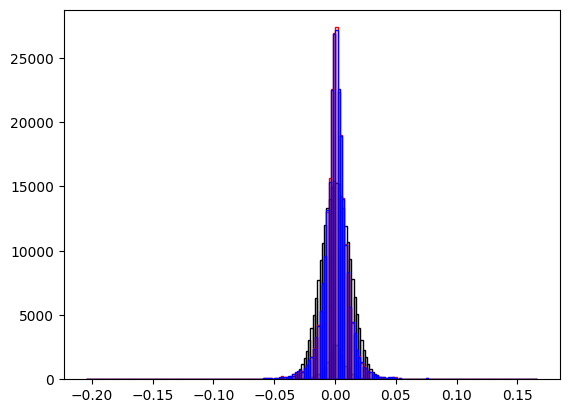

In [7]:
data_min = np.min([np.min(gbm),np.min(bootstrap),np.min(MBB)])
data_max = np.max([np.max(gbm),np.max(bootstrap),np.max(MBB)])

bins = np.linspace(data_min, data_max, 200)
plt.hist(daily_return, bins=bins, facecolor='none', edgecolor='gray')
plt.hist(gbm.flatten(), bins=bins, facecolor='none', edgecolor='black')
plt.hist(bootstrap.flatten(), bins=bins, facecolor='none', edgecolor='red')
plt.hist(MBB.flatten(), bins=bins, facecolor='none', edgecolor='blue')


In [8]:
paths = SG.run_simulate(daily_return, strategy="obpi")

In [9]:
paths

array([[ 10000.        ,  10050.8379812 ,  10171.27605039, ...,
        339829.73817487, 341223.64986007, 339983.98610031],
       [ 10000.        ,   9753.39911011,   9964.72356409, ...,
        220900.13451912, 220868.12873128, 220894.9291078 ],
       [ 10000.        ,   9993.55516424,  10118.56926554, ...,
        384381.71584843, 384381.71584843, 384381.71584843],
       ...,
       [ 10000.        ,   9956.66392897,   9973.11334547, ...,
        112802.16071269, 114772.4405194 , 114821.46101182],
       [ 10000.        ,  10191.15452698,  10071.68390929, ...,
        365352.85502001, 364784.63433528, 374714.66954771],
       [ 10000.        ,   9881.4485889 ,   9856.58434193, ...,
         45194.50349013,  45255.55565855,  45307.54821765]],
      shape=(10, 24682))